## Calculating the Hurst Exponent for India VIX and NIFTY50

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

In [2]:
def hurst_exponent(ts):
    """
    Compute Hurst exponent using R/S analysis.
    H < 0.5 → mean-reverting
    H ≈ 0.5 → random walk
    H > 0.5 → trending
    """
    lags = range(2, 20)
    tau = []
    for lag in lags:
        # std of lagged differences
        tau.append(np.std(np.subtract(ts[lag:], ts[:-lag])))
        
    # Fit log-log regression: slope = H
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]


def rolling_hurst(series, window=120):
    return series.rolling(window).apply(lambda x: hurst_exponent(x.values), raw=False)

vix = yf.Ticker("^INDIAVIX").history(period="2y")["Close"].dropna()
vix.index = vix.index.tz_localize(None)

# Rolling Hurst
window = 120
vix_hurst = rolling_hurst(vix, window=window)
vix_rank = vix.rolling(252).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
latest_vix    = vix.iloc[-1]
latest_hurst  = vix_hurst.iloc[-1]
latest_rank   = vix_rank.iloc[-1]

print(f"India VIX        : {latest_vix:.2f}")
print(f"VIX Percentile   : {latest_rank:.2%}")
print(f"Hurst Exponent   : {latest_hurst:.3f}")

if latest_rank > 0.5 and latest_hurst < 0.5:
    print("Premium is rich AND vol is mean-reverting: Sell")
elif latest_rank > 0.5 and latest_hurst >= 0.5:
    print("Premium is rich BUT vol is trending: trade smaller / wait")
elif latest_rank <= 0.5:
    print("Premium is thin: avoid or skip")

India VIX        : 25.47
VIX Percentile   : 98.41%
Hurst Exponent   : 0.483
Premium is rich AND vol is mean-reverting: Sell


## Historical RV vs current IV

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


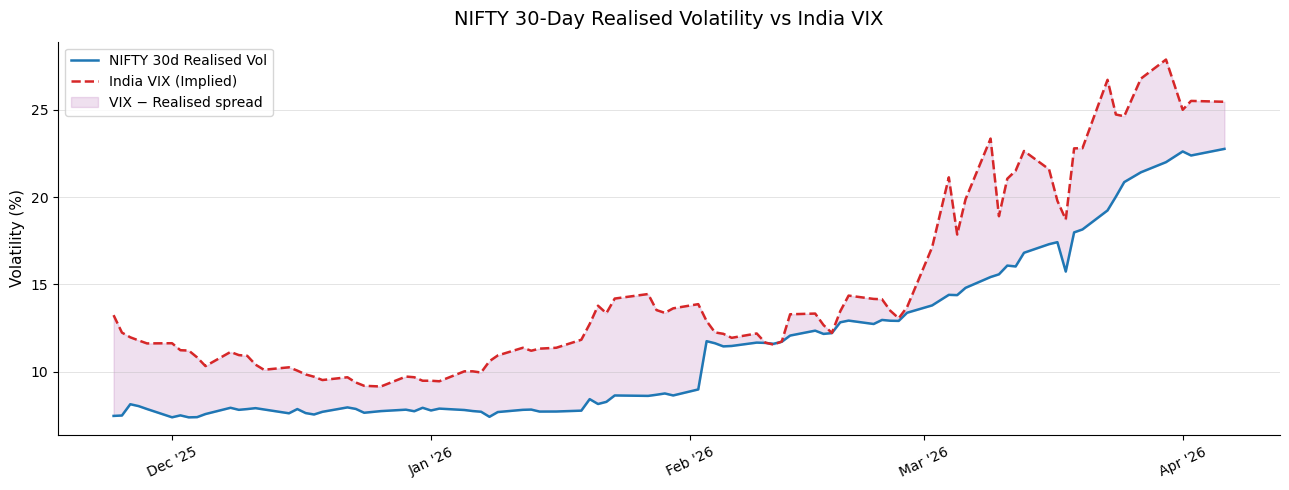

            NIFTY 30d Realised Vol (%)  India VIX (%)
Date                                                 
2026-03-19                   17.983522      22.799999
2026-03-20                   18.151468      22.809999
2026-03-23                   19.241370      26.730000
2026-03-24                   20.029683      24.740000
2026-03-25                   20.866165      24.639999
2026-03-27                   21.428499      26.799999
2026-03-30                   22.008949      27.889999
2026-04-01                   22.623411      25.010000
2026-04-02                   22.391065      25.520000
2026-04-06                   22.770008      25.469999


In [8]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# ── Parameters ──────────────────────────────────────────────────────────────
END_DATE   = datetime.today()
START_DATE = END_DATE - timedelta(days=180)   # enough history for 30-day vol
WINDOW     = 30                               # rolling window in trading days

# ── Fetch data ───────────────────────────────────────────────────────────────
nifty = yf.download("^NSEI",  start=START_DATE, end=END_DATE, auto_adjust=True)
vix   = yf.download("^INDIAVIX", start=START_DATE, end=END_DATE, auto_adjust=True)

# ── Compute 30-day realised volatility (annualised) for NIFTY ────────────────
log_ret   = np.log(nifty["Close"] / nifty["Close"].shift(1))
nifty_vol = log_ret.rolling(WINDOW).std() * np.sqrt(252) * 100   # → %

# ── Align VIX to the same date index ─────────────────────────────────────────
# India VIX is already a 30-day forward implied vol (annualised %)
vix_close = vix["Close"].reindex(nifty_vol.index, method="ffill")

# ── Keep only rows where both series are valid ────────────────────────────────
df = pd.DataFrame({
    "NIFTY 30d Realised Vol (%)": nifty_vol.squeeze(),
    "India VIX (%)":              vix_close.squeeze(),
}).dropna()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df["NIFTY 30d Realised Vol (%)"],
        label="NIFTY 30d Realised Vol", color="#1f77b4", linewidth=1.8)

ax.plot(df.index, df["India VIX (%)"],
        label="India VIX (Implied)", color="#d62728",
        linewidth=1.8, linestyle="--")

# Shaded spread between implied and realised
ax.fill_between(df.index,
                df["NIFTY 30d Realised Vol (%)"],
                df["India VIX (%)"],
                alpha=0.12, color="purple",
                label="VIX − Realised spread")

ax.set_title("NIFTY 30-Day Realised Volatility vs India VIX", fontsize=14, pad=12)
ax.set_ylabel("Volatility (%)", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=25)
ax.legend(fontsize=10)
ax.grid(axis="y", linewidth=0.4, alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("nifty_vol_vs_vix.png", dpi=150)
plt.show()
print(df.tail(10).to_string())

Fetching NIFTY 50 and India VIX...


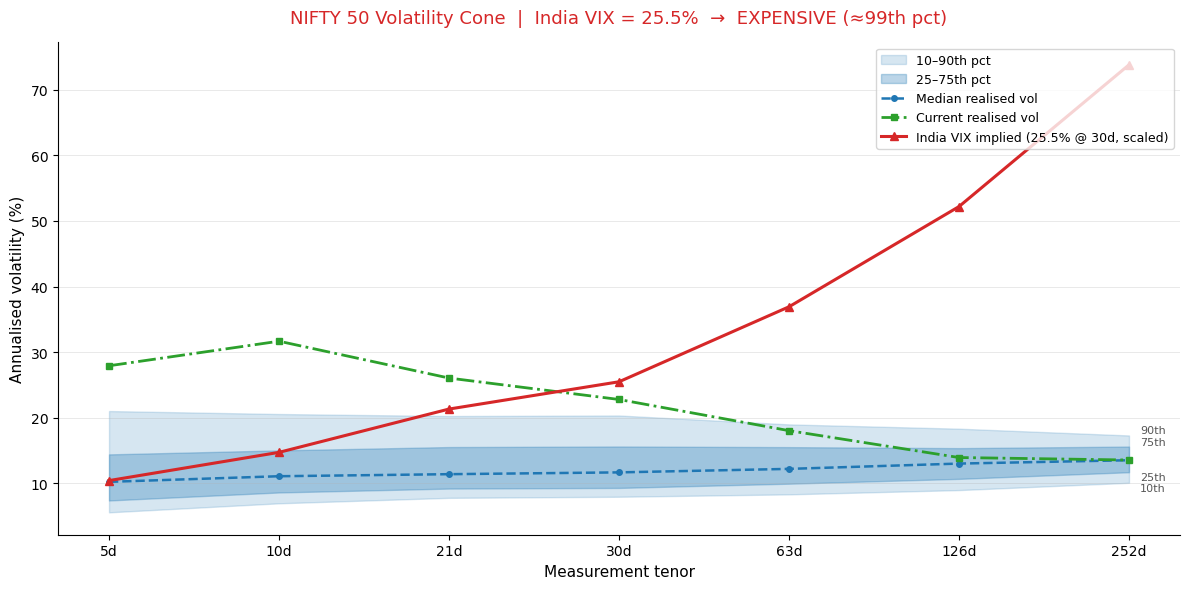


Tenor        P10     P25     P50     P75     P90   Curr RV  IV (scaled)
-----------------------------------------------------------------
5d           5.6     7.4    10.2    14.4    21.0      27.9         10.4
10d          6.9     8.6    11.1    15.0    20.6      31.7         14.7
21d          7.8     9.2    11.4    15.5    20.2      26.0         21.3
30d          7.9     9.3    11.6    15.6    20.3      22.8         25.5
63d          8.3     9.9    12.2    15.5    19.0      18.0         36.9
126d         8.9    10.7    13.0    15.3    18.3      13.9         52.2
252d        10.1    11.7    13.5    15.6    17.3      13.5         73.8

India VIX at 30d tenor sits at the ≈99th percentile of historical realised vol.


In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta

# ── Config ────────────────────────────────────────────────────────────────────
TENORS      = [5, 10, 21, 30, 63, 126, 252]          # trading days
TENOR_LBLS  = ['5d', '10d', '21d', '30d', '63d', '126d', '252d']
PERCENTILES = [10, 25, 50, 75, 90]
LOOKBACK_YRS = 5                                       # years of history for cone

END   = datetime.today()
START = END - timedelta(days=365 * LOOKBACK_YRS + 60)  # extra buffer

# ── Fetch data ────────────────────────────────────────────────────────────────
print("Fetching NIFTY 50 and India VIX...")
nifty = yf.download("^NSEI",     start=START, end=END, auto_adjust=True, progress=False)
vix   = yf.download("^INDIAVIX", start=START, end=END, auto_adjust=True, progress=False)

nifty_close = nifty["Close"].squeeze()
vix_close   = vix["Close"].squeeze().reindex(nifty_close.index, method="ffill")

log_ret = np.log(nifty_close / nifty_close.shift(1))

# ── Build cone: percentile bands of realised vol at each tenor ─────────────────
cone = {}
for t in TENORS:
    rv = log_ret.rolling(t).std() * np.sqrt(252) * 100   # annualised %
    rv = rv.dropna()
    cone[t] = {p: np.percentile(rv, p) for p in PERCENTILES}
    cone[t]["current_rv"] = rv.iloc[-1]                   # most recent realised

# ── Current implied vol from VIX at each tenor ────────────────────────────────
# India VIX is a 30-day forward implied vol. We use it directly for the 21d/30d
# point and scale for other tenors using the variance-time rule as an approximation.
# (For a proper surface you'd need options chain data.)
vix_current = vix_close.iloc[-1]

def scale_vix(vix_30d, target_tenor, base_tenor=30):
    """Rough scaling: IV ~ VIX * sqrt(target/base) — a first-order approximation."""
    return vix_30d * np.sqrt(target_tenor / base_tenor)

iv_curve = {t: scale_vix(vix_current, t) for t in TENORS}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x = list(range(len(TENORS)))

# Shaded bands
p10  = [cone[t][10]  for t in TENORS]
p25  = [cone[t][25]  for t in TENORS]
p50  = [cone[t][50]  for t in TENORS]
p75  = [cone[t][75]  for t in TENORS]
p90  = [cone[t][90]  for t in TENORS]
crv  = [cone[t]["current_rv"] for t in TENORS]
iv   = [iv_curve[t]  for t in TENORS]

ax.fill_between(x, p10, p90, alpha=0.18, color="#1f77b4", label="10–90th pct")
ax.fill_between(x, p25, p75, alpha=0.30, color="#1f77b4", label="25–75th pct")
ax.plot(x, p50, color="#1f77b4", linewidth=1.8, linestyle="--",
        marker="o", markersize=4, label="Median realised vol")

# Current realised vol
ax.plot(x, crv, color="#2ca02c", linewidth=2, linestyle="-.",
        marker="s", markersize=5, label="Current realised vol")

# Implied vol curve (scaled from VIX)
ax.plot(x, iv, color="#d62728", linewidth=2.2,
        marker="^", markersize=6, label=f"India VIX implied ({vix_current:.1f}% @ 30d, scaled)")

# Percentile annotations on right edge
for p, vals, va in [(10, p10, "top"), (25, p25, "top"),
                    (75, p75, "bottom"), (90, p90, "bottom")]:
    ax.annotate(f"{p}th", xy=(x[-1], vals[-1]),
                xytext=(8, 0), textcoords="offset points",
                fontsize=8, color="#555", va=va)

# Where does current IV sit in the cone?
iv_30d_pct = sum(1 for v in log_ret.rolling(30).std().dropna() * np.sqrt(252) * 100
                 if v <= vix_current) / len(log_ret.rolling(30).std().dropna()) * 100
regime_color = "#d62728" if iv_30d_pct > 75 else ("#2ca02c" if iv_30d_pct < 25 else "#ff7f0e")
regime_label = "EXPENSIVE" if iv_30d_pct > 75 else ("CHEAP" if iv_30d_pct < 25 else "FAIR VALUE")

ax.set_title(
    f"NIFTY 50 Volatility Cone  |  India VIX = {vix_current:.1f}%  "
    f"→  {regime_label} (≈{iv_30d_pct:.0f}th pct)",
    fontsize=13, color=regime_color, pad=14
)
ax.set_xticks(x)
ax.set_xticklabels(TENOR_LBLS)
ax.set_xlabel("Measurement tenor", fontsize=11)
ax.set_ylabel("Annualised volatility (%)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("nifty_vol_cone.png", dpi=150)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Tenor':<8}", end="")
for p in PERCENTILES:
    print(f"{'P'+str(p):>8}", end="")
print(f"{'Curr RV':>10}{'IV (scaled)':>13}")
print("-" * 65)
for t, lbl in zip(TENORS, TENOR_LBLS):
    print(f"{lbl:<8}", end="")
    for p in PERCENTILES:
        print(f"{cone[t][p]:>8.1f}", end="")
    print(f"{cone[t]['current_rv']:>10.1f}{iv_curve[t]:>13.1f}")
print(f"\nIndia VIX at 30d tenor sits at the ≈{iv_30d_pct:.0f}th percentile of historical realised vol.")